# Skenario 01 — Build Model Final

Notebook ini membaca hasil ABC dan PSO, membandingkan empat kandidat berdasarkan MSE cross-validation, melatih ulang seluruh kandidat pada semua status data, dan menyimpan satu model terbaik. Jalankan notebook ABC dan PSO terlebih dahulu.

In [1]:
from pathlib import Path
import json
import shutil

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

SEED = 42
SENSOR_COLS = [
    "Exhaust Gas Temperature LF (Left Front)",
    "Exhaust Gas Temperature LR (Left Rear)",
    "Exhaust Gas Temperature RF (Right Front)",
    "Exhaust Gas Temperature RR (Right Rear)",
    "Blowby Pressure (Kpa)",
    "Boost Pressure (Kpa)",
    "Engine Oil Temp (°C)",
    "Coolant Temp (°C)",
]
LIFE_COL = "Unit Lifetime (Hour)"
STATUS_COL = "Status"
TARGET_COL = "sisa jam"
FEATURE_COLS = SENSOR_COLS.copy()
DATA_FILE = "datas/Data_PT.Amanah_Critical_Break.xlsx"
MAX_RUL = 2550.0
PRIMARY_THRESHOLD = 250

## Muat data dan hasil optimasi

In [2]:
def find_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / DATA_FILE).exists():
            return path
    raise FileNotFoundError(f"Dataset tidak ditemukan: {DATA_FILE}")

def prepare_data(root):
    raw = pd.read_excel(root / DATA_FILE)
    data = raw[[*FEATURE_COLS, LIFE_COL, STATUS_COL]].copy()
    for col in FEATURE_COLS:
        data[col] = pd.to_numeric(data[col], errors="coerce")
    data[LIFE_COL] = pd.to_numeric(data[LIFE_COL], errors="coerce")
    data[STATUS_COL] = data[STATUS_COL].astype("string").str.strip().str.casefold()
    break_hour = data.loc[data[STATUS_COL].eq("break"), LIFE_COL].max()
    if pd.isna(break_hour):
        raise ValueError("Baris berstatus Break diperlukan untuk membentuk target sisa jam")
    data[TARGET_COL] = (break_hour - data[LIFE_COL]).clip(lower=0, upper=MAX_RUL)
    data = data.dropna(subset=[*FEATURE_COLS, STATUS_COL, TARGET_COL]).copy()
    return data, float(break_hour)

root = find_root()
scenario_dir = root / "newcode/scenarios/01_RF_SVR_data_single"
artifact_dir = scenario_dir / "artifacts"
model_dir = scenario_dir / "models"
model_dir.mkdir(parents=True, exist_ok=True)
data, break_hour = prepare_data(root)
candidates = {}
for optimizer in ["abc", "pso"]:
    for kind in ["rf", "svr"]:
        key = f"{optimizer}_{kind}"
        path = artifact_dir / key / "metrics.json"
        if not path.exists():
            raise FileNotFoundError(f"Hasil belum tersedia: {path}. Jalankan notebook optimasi terkait.")
        item = json.loads(path.read_text(encoding="utf-8"))
        if item.get("data_scope") != "all_status":
            raise ValueError(f"Artefak {key} masih memakai filter Critical. Jalankan ulang notebook optimasi.")
        if item.get("feature_scope") != "sensor_only":
            raise ValueError(f"Artefak {key} masih memakai lifetime sebagai fitur. Jalankan ulang notebook optimasi.")
        if not item.get("threshold_metrics"):
            raise ValueError(f"Artefak {key} belum memiliki validasi ambang batas. Jalankan ulang notebook optimasi.")
        candidates[key] = item
comparison = pd.DataFrame(candidates).T.sort_values("cv_mse")
metric_cols = [
    "optimizer", "model", "cv_mse", "cv_rmse",
    "test_mse", "test_rmse", "test_mae", "test_r2", "objective_evaluations",
]
threshold_rows = []
for key, item in candidates.items():
    for row in item["threshold_metrics"]:
        threshold_rows.append({"candidate": key, **row})
threshold_comparison = pd.DataFrame(threshold_rows)
primary_cv = threshold_comparison.loc[
    threshold_comparison["scope"].eq("cv_oof")
    & threshold_comparison["threshold"].eq(PRIMARY_THRESHOLD)
].set_index("candidate")
display(comparison[metric_cols])
display(primary_cv[["tp", "tn", "fp", "fn", "accuracy", "precision", "recall", "f1"]])

,optimizer,model,cv_mse,cv_rmse,test_mse,test_rmse,test_mae,test_r2,objective_evaluations
pso_svr,PSO,SVR,13361.356165,115.591333,11163.182933,105.655965,57.39416,0.978838,320
abc_svr,ABC,SVR,13361.374453,115.591412,11172.17004,105.698486,57.419824,0.978821,398
abc_rf,ABC,Random Forest,24087.552169,155.20165,16681.476728,129.156791,64.69091,0.968377,517
pso_rf,PSO,Random Forest,24118.341581,155.30081,16012.65904,126.541136,66.967249,0.969645,299


,tp,tn,fp,fn,accuracy,precision,recall,f1
candidate,,,,,,,,
abc_rf,148,1848,0,58,0.971762,1.000000,0.718447,0.836158
abc_svr,140,1837,11,66,0.962512,0.927152,0.679612,0.784314
pso_rf,148,1848,0,58,0.971762,1.000000,0.718447,0.836158
pso_svr,140,1837,11,66,0.962512,0.927152,0.679612,0.784314


## Latih seluruh kandidat dan simpan model terbaik

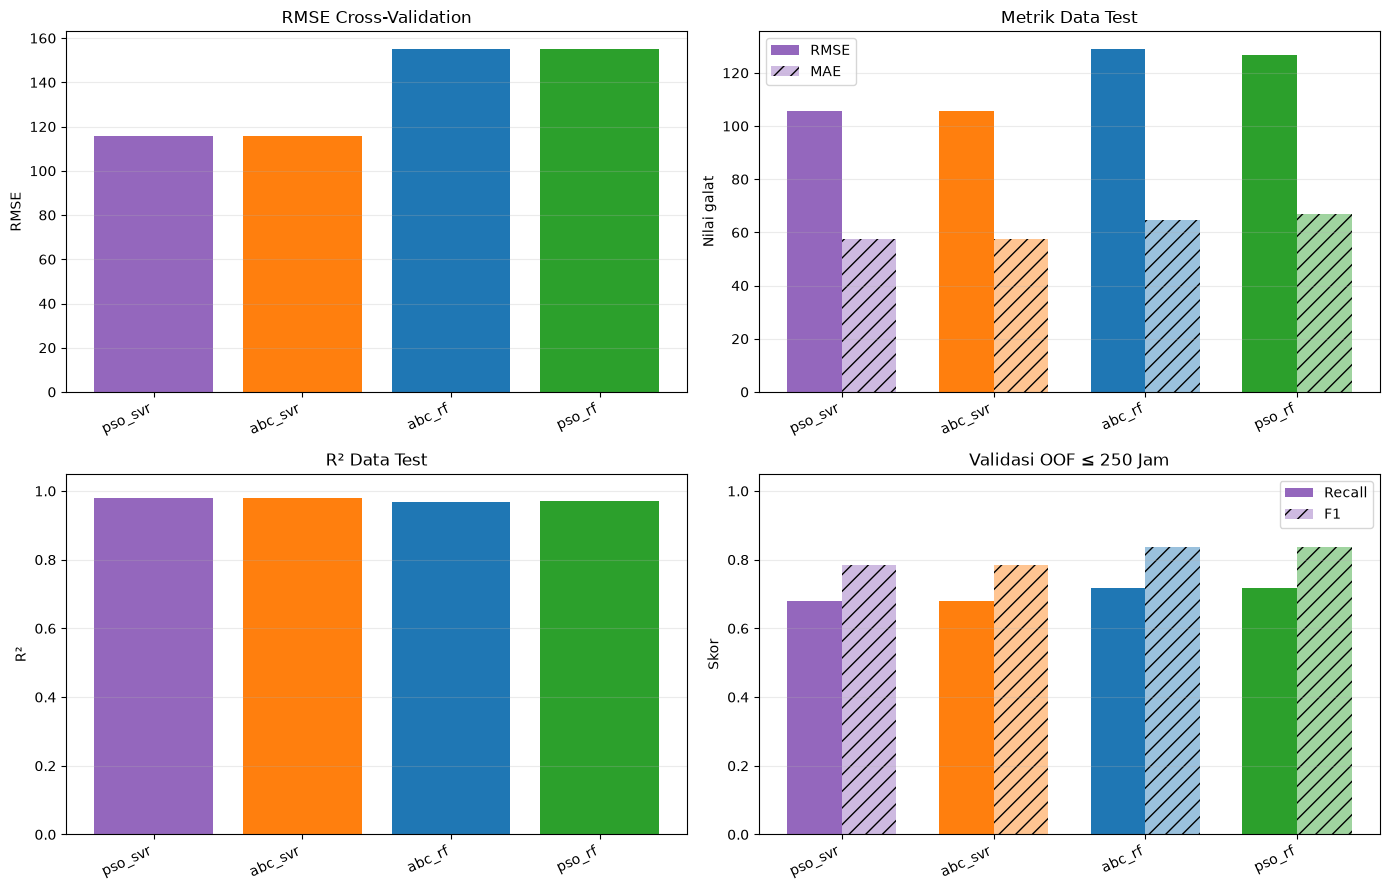

,optimizer,model,cv_mse,cv_rmse,test_mse,test_rmse,test_mae,test_r2,objective_evaluations,train_mse_diagnostic,train_rmse_diagnostic,train_mae_diagnostic,train_r2_diagnostic
candidate,,,,,,,,,,,,,
pso_svr,PSO,SVR,13361.356165,115.591333,11163.182933,105.655965,57.39416,0.978838,320,3891.189604,62.379400,26.137209,0.992917
abc_svr,ABC,SVR,13361.374453,115.591412,11172.17004,105.698486,57.419824,0.978821,398,3899.900462,62.449183,26.180502,0.992902
abc_rf,ABC,Random Forest,24087.552169,155.20165,16681.476728,129.156791,64.69091,0.968377,517,2035.107439,45.112165,21.315970,0.996296
pso_rf,PSO,Random Forest,24118.341581,155.30081,16012.65904,126.541136,66.967249,0.969645,299,2136.555923,46.222894,22.705674,0.996111


{'selected_model': 'pso_svr',
 'data_scope': 'all_status',
 'feature_scope': 'sensor_only',
 'selection_metric': 'cv_mse',
 'target': 'sisa jam',
 'features': ['Exhaust Gas Temperature LF (Left Front)',
  'Exhaust Gas Temperature LR (Left Rear)',
  'Exhaust Gas Temperature RF (Right Front)',
  'Exhaust Gas Temperature RR (Right Rear)',
  'Blowby Pressure (Kpa)',
  'Boost Pressure (Kpa)',
  'Engine Oil Temp (°C)',
  'Coolant Temp (°C)'],
 'training_rows': 2568,
 'status_counts': {'normal': 1847, 'critical': 720, 'break': 1},
 'break_hour': 78637.0,
 'primary_threshold_hours': 250,
 'best_params': {'C': 1000.0,
  'epsilon': 0.001,
  'gamma': 0.4011804350173628,
  'kernel': 'rbf'},
 'optimizer_results': {'abc_rf': {'optimizer': 'ABC',
   'model': 'Random Forest',
   'data_scope': 'all_status',
   'feature_scope': 'sensor_only',
   'target': 'sisa jam',
   'features': ['Exhaust Gas Temperature LF (Left Front)',
    'Exhaust Gas Temperature LR (Left Rear)',
    'Exhaust Gas Temperature RF (

In [3]:
def make_model(kind, params):
    if kind == "rf":
        return RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
    return Pipeline([("scale", StandardScaler()), ("svr", SVR(**params))])

def metric_values(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    return {
        "mse": float(mse),
        "rmse": float(np.sqrt(mse)),
        "mae": float(mean_absolute_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)),
    }

X, y = data[FEATURE_COLS], data[TARGET_COL]
model_paths = {}
train_metrics = {}
reload_checks = {}
training_predictions = data[[LIFE_COL, STATUS_COL, TARGET_COL]].copy()
training_predictions = training_predictions.rename(columns={TARGET_COL: "actual_sisa_jam"})
for key, item in candidates.items():
    kind = key.rsplit("_", 1)[1]
    model = make_model(kind, item["best_params"])
    model.fit(X, y)
    predicted = model.predict(X)
    train_metrics[key] = metric_values(y, predicted)
    training_predictions[f"predicted_{key}"] = predicted
    path = model_dir / f"{key}.joblib"
    joblib.dump(model, path)
    loaded = joblib.load(path)
    reload_checks[key] = bool(np.allclose(predicted, loaded.predict(X)))
    model_paths[key] = str(path.relative_to(root))

if not all(reload_checks.values()):
    raise RuntimeError("Prediksi berubah setelah model dimuat ulang")

for key, values in train_metrics.items():
    for metric, value in values.items():
        comparison.loc[key, f"train_{metric}_diagnostic"] = value
comparison.index.name = "candidate"
comparison.reset_index().to_csv(model_dir / "model_comparison.csv", index=False)
threshold_comparison.to_csv(model_dir / "threshold_comparison.csv", index=False)
training_predictions.to_csv(model_dir / "training_predictions.csv", index=False)

best_key = min(candidates, key=lambda key: candidates[key]["cv_mse"])
best_path = model_dir / f"{best_key}.joblib"
shutil.copy2(best_path, model_dir / "best_model.joblib")
summary = {
    "selected_model": best_key,
    "data_scope": "all_status",
    "feature_scope": "sensor_only",
    "selection_metric": "cv_mse",
    "target": TARGET_COL,
    "features": FEATURE_COLS,
    "training_rows": len(data),
    "status_counts": {str(key): int(val) for key, val in data[STATUS_COL].value_counts().items()},
    "break_hour": break_hour,
    "primary_threshold_hours": PRIMARY_THRESHOLD,
    "best_params": candidates[best_key]["best_params"],
    "optimizer_results": candidates,
    "training_metrics_diagnostic": train_metrics,
    "primary_threshold_cv": primary_cv.reset_index().to_dict(orient="records"),
    "model_paths": model_paths,
    "reload_prediction_checks": reload_checks,
}
(model_dir / "build_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

colors = {"abc_rf": "tab:blue", "abc_svr": "tab:orange", "pso_rf": "tab:green", "pso_svr": "tab:purple"}
plot_df = comparison.sort_values("cv_rmse")
keys = plot_df.index.tolist()
x = np.arange(len(keys))
bar_colors = [colors[key] for key in keys]
primary_plot = primary_cv.reindex(keys)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].bar(x, plot_df["cv_rmse"], color=bar_colors)
axes[0, 0].set(title="RMSE Cross-Validation", ylabel="RMSE")
axes[0, 1].bar(x - 0.18, plot_df["test_rmse"], 0.36, color=bar_colors, label="RMSE")
axes[0, 1].bar(x + 0.18, plot_df["test_mae"], 0.36, color=bar_colors, alpha=0.45, hatch="//", label="MAE")
axes[0, 1].set(title="Metrik Data Test", ylabel="Nilai galat")
axes[0, 1].legend()
axes[1, 0].bar(x, plot_df["test_r2"], color=bar_colors)
axes[1, 0].set(title="R² Data Test", ylabel="R²", ylim=(0, 1.05))
axes[1, 1].bar(x - 0.18, primary_plot["recall"], 0.36, color=bar_colors, label="Recall")
axes[1, 1].bar(x + 0.18, primary_plot["f1"], 0.36, color=bar_colors, alpha=0.45, hatch="//", label="F1")
axes[1, 1].set(title=f"Validasi OOF ≤ {PRIMARY_THRESHOLD} Jam", ylabel="Skor", ylim=(0, 1.05))
axes[1, 1].legend()
for ax in axes.flat:
    ax.set_xticks(x, keys, rotation=25, ha="right")
    ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(model_dir / "model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()
display(comparison[[*metric_cols, "train_mse_diagnostic", "train_rmse_diagnostic", "train_mae_diagnostic", "train_r2_diagnostic"]])
summary